

---


# **Subject : Automatically categorize questions on Stackoverflow**





---











To ask a question un StackOverflow, people need to select some tags in order to maximize their chance to get an answer. In this project, we are volunteer to help StackOverflow by developping an algorithm that will suggest tags based on the title and/or the content of the question.

For doing this, we will need first get some data for training and testing our algorithms. StackOverflow offers a data export tool, "[StackExchange Data Explorer](https://data.stackexchange.com/stackoverflow/query/new)", which lists a large amount of authentic data from the platform.
Therefore you can run the following query in this data export tool to create your dataset and download it:

```
SELECT TOP 10000 Title, Body, Tags, Score, ViewCount, FavoriteCount, AnswerCount, CreationDate
FROM Posts
WHERE ViewCount > 10
AND AnswerCount > 5
AND LEN(Tags) - LEN(REPLACE(Tags, '<','')) <= 4
AND LEN(Tags) - LEN(REPLACE(Tags, '<','')) >= 1
```

If you can't download the data by yourself, you can use the files available in this link : [here](https://1drv.ms/f/c/ab584826bfa6bf60/EmC_pr8mSFgggKuwDgAAAAABUQ7Gb55TD9Sc_u27Dezm2A?e=0Tw5fz)


Below are the steps required to fullful this project :



1.   Process the "Tags" column in order to compute some statistics : wordcloud on the tags, bar diagram with the 20 most common tags
2.   Filter the dataset to keep only rows containing the top 10 tags
3.   Combine the title and the body of the question for the analysis. Apply cleaning process on the corpus (title+body)
4.   Implement an unsupervised approach (LDA for example) to identify main topics/key word on the dataset. Propose some graphics to illustrate the results
5.   Implement a supervised approach to predict the tags (use [this first example](https://www.kaggle.com/discussions/questions-and-answers/66693) to process the target into multiple binary outputs and [this second example](https://dongr0510.medium.com/multi-label-classification-example-with-multioutputclassifier-and-xgboost-in-python-98c84c7d379f) to know how to predicting a multilabel target). Make sure to test and compare the following feature extraction methods :

    *   1 bag-of-word approach : TF-IDF or CountVectorizer
    *   2 word embedding approach among these : Word2Vec, Glove, BERT, USE

  For the word embedding part, you can use [this example of notebook](https://s3.eu-west-1.amazonaws.com/course.oc-static.com/projects/Data_Scientist_P6/Exemple_Tweets_Feature-extraction_Sentence+Embedding_V1.1.ipynb) to help you explore Word2Vec, Doc2Vec, Glove, BERT et USE.

  For the supervised task, test 2 or more models and tune hyperparameters if possible.

6.   Evaluate and compare the models trained after using a train/test split


In [1]:
# Imports

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import re
import nltk
from bs4 import BeautifulSoup
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mouad\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mouad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_csv('QueryResults.csv')

In [4]:
df.head()

,Title,Body,Tags,Score,ViewCount,FavoriteCount,AnswerCount,CreationDate
0,How to override the properties of a CSS class ...,<p>I am fairly new to CSS3 and I want to be ab...,<css><class><overriding>,122,463698,0.0,6,2014-01-06 16:38:24
1,toString() of int e = 0000007 omits all zeros....,<p>I'm trying to write a program in C# that ta...,<c#><numbers><int>,2,668,0.0,9,2010-01-25 08:50:48
2,The fastest way to check if some records in a ...,<p>I have a huge table to work with . I want t...,<database><oracle><hibernate>,10,22104,0.0,6,2010-01-25 09:03:42
3,Can you make valid Makefiles without tab chara...,<pre><code>target: dependencies\n command1\...,<makefile><tabs><whitespace><spaces>,134,70813,0.0,10,2010-01-25 09:15:56
4,CSS - Margins a bad thing?,<p>I've noticed that some browsers have troubl...,<html><css><margin>,5,856,0.0,6,2010-01-25 09:03:52


### 1. **Processing "Tags"**

In [5]:
## Transform tags values into list of tags
def process_tag(s):
  return(list(filter(None, re.split(r'<|>' , s))))

df['tag_list'] =  df.Tags.apply(process_tag)
df[['Tags', 'tag_list']].head()

,Tags,tag_list
0,<css><class><overriding>,"[css, class, overriding]"
1,<c#><numbers><int>,"[c#, numbers, int]"
2,<database><oracle><hibernate>,"[database, oracle, hibernate]"
3,<makefile><tabs><whitespace><spaces>,"[makefile, tabs, whitespace, spaces]"
4,<html><css><margin>,"[html, css, margin]"


In [6]:
# Get list of all tags
l_tags = df.tag_list.apply(lambda x : " ".join(x)).tolist()
all_tags = " ".join(l_tags)
all_tags

'css class overriding c# numbers int database oracle hibernate makefile tabs whitespace spaces html css margin regex comparison formal-languages php mysql passwords encryption python documentation standard-library c# generics dictionary filtering java operators angular angular-cli ios objective-c uiview c# coding-style assert language-agnostic pointers null hex php string arrays casting spring-boot spring-cloud-netflix spring-cloud-config css user-interface sql python django java google-sheets google-sheets-api google-workspace ios swift ios10 html forms lastpass ruby instance-variables private-members java unit-testing homebrew formula wine macos-catalina java soap rest java java arraylist javascript null text macros text-editor forms delphi javascript jquery javascript regex javascript jquery text iphone mkmapview mkannotation java aop python list find indexing php cakephp cakephp-2.4 java equals hashcode language-agnostic design-patterns c# .net regex csv awk sed c# azure azure-keyv

In [7]:
# List of unique tags
unique_tags = np.unique(all_tags.split(' '))
len(unique_tags)

4000

In [8]:
# Count of occurence of tags
(pd.DataFrame(all_tags.split(' '), columns = ['tag'])\
  .groupby('tag').agg({'tag' : 'count'})\
  .rename(columns={'tag': 'count'})\
  .reset_index()\
  .sort_values('count', ascending = False)\
  .head(15))

,tag,count
456,c#,1198
1817,java,968
461,c++,668
2,.net,642
1834,javascript,623
2737,python,591
2576,php,490
3211,sql,367
1596,html,362
235,asp.net,359


In [ ]:
## TODO :=> wordcloud on the tags, bar diagram with the 20 most common tags

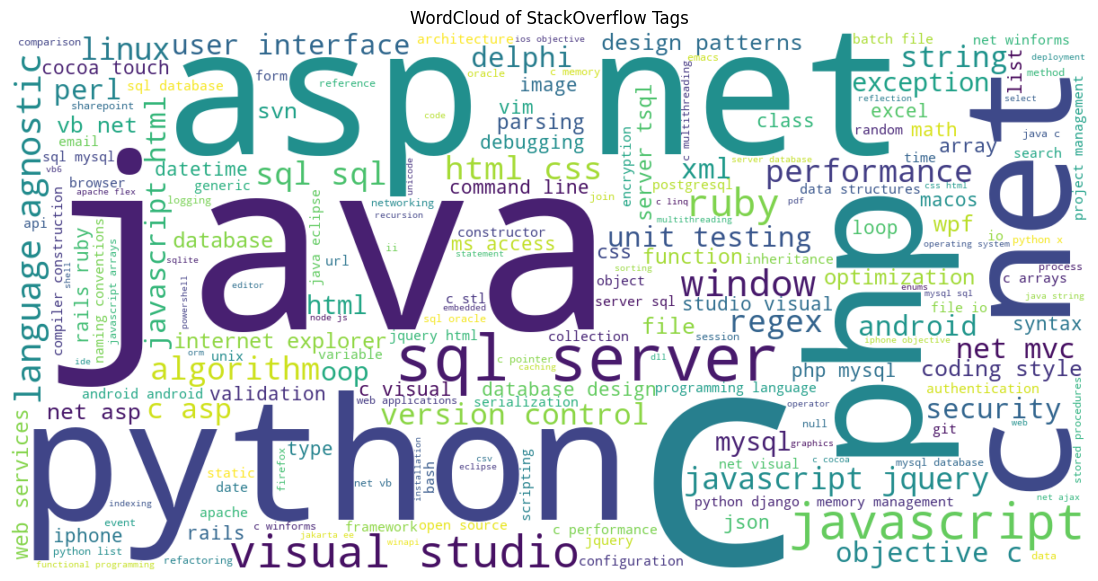

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(all_tags)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of StackOverflow Tags")
plt.show()

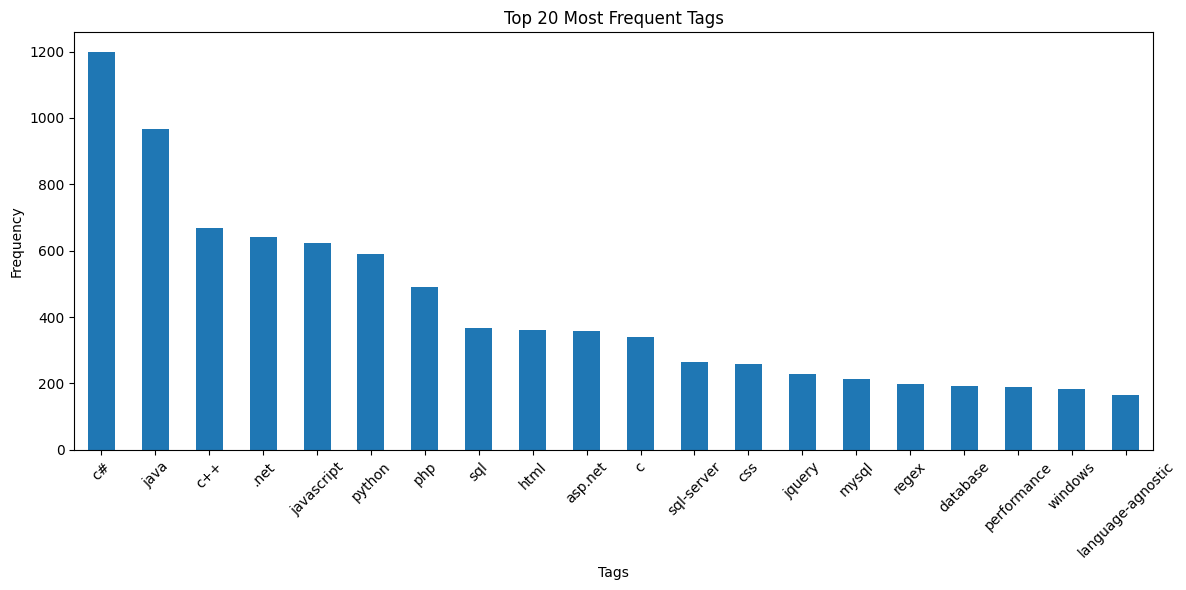

In [10]:
tag_counts = (
    pd.DataFrame(all_tags.split(' '), columns=['tag'])
      .groupby('tag')
      .size()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(12,6))
tag_counts.plot(kind="bar")

plt.title("Top 20 Most Frequent Tags")
plt.xlabel("Tags")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. **Filter dataset**

In [11]:
tag_counts = (
    pd.DataFrame(all_tags.split(' '), columns=['tag'])
      .groupby('tag')
      .size()
      .sort_values(ascending=False)
)

most_frequent_tags = tag_counts.head(10).index.tolist()

print(most_frequent_tags)

['c#', 'java', 'c++', '.net', 'javascript', 'python', 'php', 'sql', 'html', 'asp.net']


In [12]:
## TODO :=> Take the real list of 10 most frequent tags
most_frequent_tags = ['c#', 'java', 'c++', '.net', 'javascript', 'python', 'php', 'sql', 'html', 'asp.net']
def intersection(lst1, lst2):
    return list(set(lst1) & set(lst2))

def keep_indicator(l_tags):
  intersect = intersection(l_tags, most_frequent_tags)
  return(int(len(intersect) > 0))

keep_indicator(['tag', "c"])

0

In [13]:
# Create indicator for keeping row or not
df['keep_indicator'] = df['tag_list'].apply(keep_indicator)
df[['tag_list', 'keep_indicator']].head()

,tag_list,keep_indicator
0,"[css, class, overriding]",0
1,"[c#, numbers, int]",1
2,"[database, oracle, hibernate]",0
3,"[makefile, tabs, whitespace, spaces]",0
4,"[html, css, margin]",1


In [14]:
# Clean the tag_list for keeping only selected tags => this cleaned column will be used for modeling
def simplify_tag_list(l):
  return([x for x in l if x in most_frequent_tags])

df['tag_list_final'] = df['tag_list'].apply(simplify_tag_list)
df['n_tags'] = df['tag_list_final'].apply(lambda x : len(x))
df[['tag_list', 'keep_indicator', 'tag_list_final', 'n_tags']].sort_values('n_tags', ascending = False).head(5)

,tag_list,keep_indicator,tag_list_final,n_tags
2547,"[c#, .net, asp.net, javascript]",1,"[c#, .net, asp.net, javascript]",4
4063,"[c#, .net, asp.net, file-upload]",1,"[c#, .net, asp.net]",3
1452,"[c#, asp.net, .net]",1,"[c#, asp.net, .net]",3
8127,"[c#, asp.net, sql, visual-studio-2010]",1,"[c#, asp.net, sql]",3
1750,"[c#, .net, asp.net, asp.net-mvc]",1,"[c#, .net, asp.net]",3


In [ ]:
## TODO :=> Filter the dataset to keep only rows with selected tags


In [25]:
# Filter the dataset to keep only rows containing at least one of the top 10 tags
df_filtered = df[df["keep_indicator"] == 1].copy()

print("Original dataset :", df.shape)
print("Filtered dataset :", df_filtered.shape)

# Replace the original dataframe
df = df_filtered

# Reset the index
df.reset_index(drop=True, inplace=True)

# Check
print(df.index)

Original dataset : (5447, 13)
Filtered dataset : (5447, 13)
RangeIndex(start=0, stop=5447, step=1)


In [26]:
df[["tag_list_final", "n_tags"]].head()

,tag_list_final,n_tags
0,[c#],1
1,[html],1
2,[php],1
3,[python],1
4,[c#],1


In [27]:
print((df["n_tags"] == 0).sum())

0


### 3. **Cleaning process**

In [28]:
# TODO :=> complete the cleaning function to add classical cleaning process in NLP (prefer lemmatizing to stemming :)  )
# Concatenate Title & body, then clean

import re
import string
import nltk

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [29]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mouad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mouad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mouad\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [30]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def remove_tags(text):
    soup = BeautifulSoup(text, "html.parser")

    for data in soup(["style", "script"]):
        data.decompose()

    return " ".join(soup.stripped_strings)


def clean_text(text):

    # lowercase
    s = text.lower()

    # remove html
    s = remove_tags(s)

    # remove line breaks
    s = re.sub(r"\n", " ", s)

    # remove html entities
    s = re.sub(r"(&lt;)|(&gt;)|(&amp;)", " ", s)

    # remove urls
    s = re.sub(r"http\S+|www\S+", " ", s)

    # remove numbers
    s = re.sub(r"\d+", " ", s)

    # remove punctuation
    s = s.translate(str.maketrans("", "", string.punctuation))

    # remove extra spaces
    s = re.sub(r"\s+", " ", s).strip()

    # tokenize
    words = s.split()

    # remove stopwords
    words = [w for w in words if w not in stop_words]

    # lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [31]:
df["text"] = (
    df[["Title", "Body"]]
      .apply(" ".join, axis=1)
      .apply(clean_text)
)

In [32]:
print("Title")
print(df.loc[0, "Title"])

print("\nBody")
print(df.loc[0, "Body"][:500])

print("\nCleaned text")
print(df.loc[0, "text"][:500])

Title
toString() of int e = 0000007 omits all zeros. How can I preserve them?

Body
<p>I'm trying to write a program in C# that takes in an int x and decides if it has exactly 7 digits. Right now I'm using x.toString().Length == 7 to check, but I noticed that if the number starts with 0, it automatically gets omitted and I get an incorrect answer (ie the program thinks the input length is less than 7)</p>

<p>Is there a way to fix this? Thanks in advance.</p>

<p>Edit: Sorry I should have mentioned, this was a program to collect and validate the format of ID numbers (so I didn'

Cleaned text
tostring int e omits zero preserve im trying write program c take int x decides exactly digit right im using xtostringlength check noticed number start automatically get omitted get incorrect answer ie program think input length le way fix thanks advance edit sorry mentioned program collect validate format id number didnt want something like default thanks string input suggestion think im going try

In [34]:
print(df.index)

RangeIndex(start=0, stop=5447, step=1)


### 4. **Unsupervised approach**

In [35]:
# TODO :=> apply an unsupervised approach
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
import numpy as np

In [36]:
# Create the document-term matrix
vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,
    stop_words="english"
)

X = vectorizer.fit_transform(df["text"])

print(X.shape)

(5447, 3901)


In [37]:
n_topics = 10

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(X)

LatentDirichletAllocation(random_state=42)

In [38]:
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]

    print(f"Topic {topic_idx+1}:")
    print(", ".join(top_words))
    print()

Topic 1:
table, sql, query, select, row, column, date, px, database, like

Topic 2:
page, user, thread, event, form, exception, error, message, control, using

Topic 3:
number, int, time, return, code, string, way, case, value, like

Topic 4:
im, use, application, like, python, net, good, using, code, language

Topic 5:
class, public, method, void, return, new, static, private, object, type

Topic 6:
string, php, using, new, image, xml, im, function, use, value

Topic 7:
way, aspnet, using, like, use, im, need, user, web, site

Topic 8:
file, java, error, application, run, project, version, line, window, using

Topic 9:
string, array, object, int, list, return, code, char, value, new

Topic 10:
function, javascript, div, var, code, element, like, value, html, script



In [39]:
def plot_top_words(model, feature_names, topic, n_top_words=10):

    weights = model.components_[topic]
    top_features = weights.argsort()[-n_top_words:][::-1]

    plt.figure(figsize=(8,5))

    plt.barh(
        [feature_names[i] for i in top_features][::-1],
        weights[top_features][::-1]
    )

    plt.title(f"Top words - Topic {topic+1}")
    plt.xlabel("Weight")
    plt.tight_layout()
    plt.show()

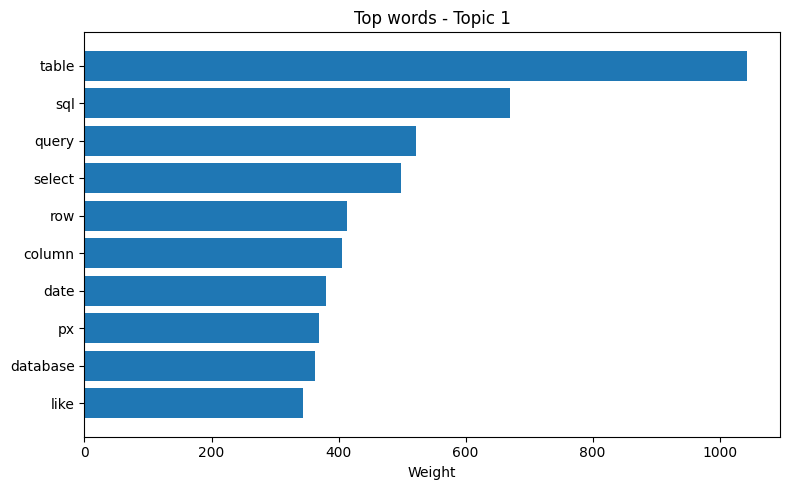

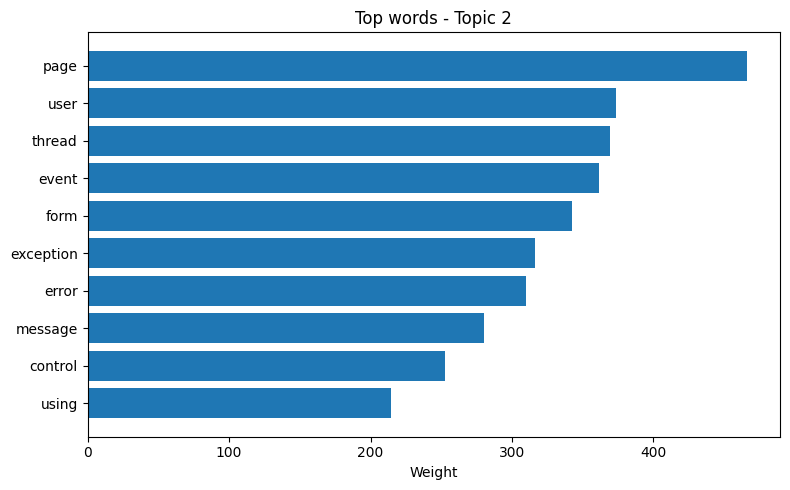

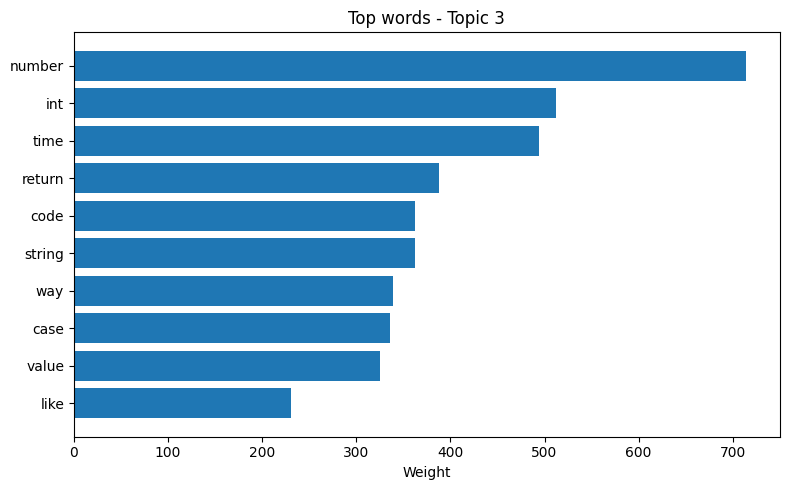

In [40]:
for i in range(3):
    plot_top_words(lda, feature_names, i)

#### The first topic is clearly related to database management and SQL queries. The most representative words, such as "sql", "query", "table", "select", "database", and "column", indicate that this topic groups together questions about relational databases, data retrieval, and SQL programming.
#### This topic mainly focuses on web application development. Keywords such as "page", "user", "form", "event", "control", and "exception" suggest discussions related to web interfaces, user interactions, and application events.
#### The third topic contains common programming terms such as "string", "return", "code", "value", "int", and "number". It appears to represent general programming questions rather than a specific programming language or technology.

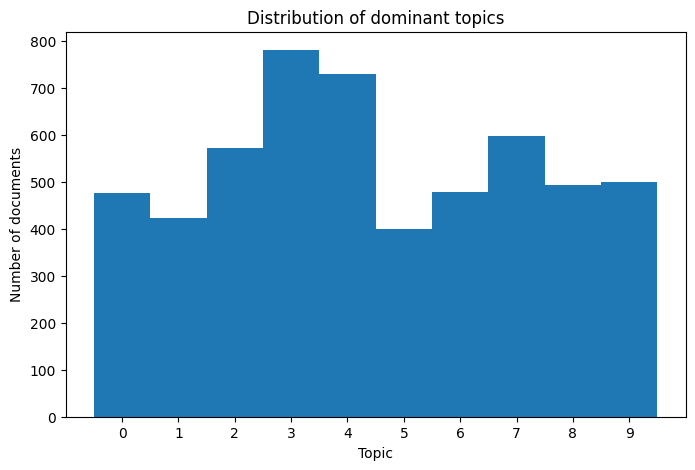

In [41]:
topic_distribution = lda.transform(X)

dominant_topic = np.argmax(topic_distribution, axis=1)

plt.figure(figsize=(8,5))
plt.hist(dominant_topic, bins=np.arange(n_topics+1)-0.5)

plt.xticks(range(n_topics))
plt.xlabel("Topic")
plt.ylabel("Number of documents")
plt.title("Distribution of dominant topics")
plt.show()

#### The LDA model successfully identified several meaningful topics within the StackOverflow dataset. Most of the discovered topics correspond to well-known programming domains such as SQL databases, Java, PHP, Python, JavaScript, ASP.NET, and object-oriented programming. Although some generic terms (e.g., "code", "using", "like") appear across multiple topics, the overall topic separation is coherent and reflects the diversity of technical discussions on StackOverflow. These results confirm that the text preprocessing stage was effective and provide a useful exploratory analysis before applying supervised multi-label classification.

### 5. **Supervised approach**

In [ ]:
# TODO :=> apply word embeddings and supervised approaches


In [42]:
# transformer les tags
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(df["tag_list_final"])

print(Y.shape)

print(mlb.classes_)

(5447, 10)
['.net' 'asp.net' 'c#' 'c++' 'html' 'java' 'javascript' 'php' 'python'
 'sql']


In [43]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["text"],
    Y,
    test_size=0.2,
    random_state=42
)

In [44]:
# Première approche : TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train = tfidf.fit_transform(X_train_text)

X_test = tfidf.transform(X_test_text)

In [45]:
# Modèle 1 : Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

clf_lr = MultiOutputClassifier(
    LogisticRegression(max_iter=1000)
)

clf_lr.fit(X_train, y_train)

y_pred_lr = clf_lr.predict(X_test)

In [46]:
# Évaluation
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=mlb.classes_
))

              precision    recall  f1-score   support

        .net       0.95      0.17      0.29       112
     asp.net       0.95      0.22      0.36        86
          c#       0.71      0.21      0.33       228
         c++       0.95      0.31      0.46       131
        html       0.84      0.29      0.43        73
        java       0.97      0.52      0.68       201
  javascript       0.92      0.53      0.67       137
         php       0.98      0.52      0.68        93
      python       0.99      0.59      0.74       114
         sql       0.95      0.48      0.64        83

   micro avg       0.92      0.38      0.54      1258
   macro avg       0.92      0.38      0.53      1258
weighted avg       0.91      0.38      0.52      1258
 samples avg       0.42      0.40      0.41      1258



C:\Users\mouad\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


##### Analyse

On observe que la régression logistique obtient une très forte précision (92%), ce qui signifie que lorsqu'un tag est prédit, il est généralement correct. En revanche, le rappel est relativement faible (38%), indiquant que le modèle manque un nombre important de tags pertinents. Par conséquent, le F1-score global atteint seulement 0.54, ce qui montre que le modèle reste conservateur dans ses prédictions.

In [48]:
# Modèle 2 : Linear SVM
from sklearn.svm import LinearSVC

clf_svm = MultiOutputClassifier(
    LinearSVC()
)

clf_svm.fit(X_train, y_train)

y_pred_svm = clf_svm.predict(X_test)

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=mlb.classes_
))

              precision    recall  f1-score   support

        .net       0.56      0.33      0.42       112
     asp.net       0.94      0.55      0.69        86
          c#       0.62      0.50      0.55       228
         c++       0.87      0.54      0.67       131
        html       0.83      0.55      0.66        73
        java       0.92      0.70      0.80       201
  javascript       0.90      0.71      0.79       137
         php       0.96      0.73      0.83        93
      python       0.99      0.83      0.90       114
         sql       0.92      0.73      0.82        83

   micro avg       0.83      0.61      0.71      1258
   macro avg       0.85      0.62      0.71      1258
weighted avg       0.83      0.61      0.70      1258
 samples avg       0.65      0.64      0.64      1258



C:\Users\mouad\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


##### Analyse

Le modèle Linear SVM obtient un meilleur équilibre entre précision et rappel. Bien que sa précision diminue légèrement (83%), son rappel augmente fortement à 61%, ce qui lui permet d'identifier davantage de tags corrects. Cette amélioration se traduit par un F1-score de 0.71, nettement supérieur à celui de la régression logistique.

In [52]:
# Import the libraries required to build Word2Vec document embeddings
from gensim.models import Word2Vec
import numpy as np

In [53]:
# Split each cleaned document into a list of words
sentences = df["text"].apply(str.split).tolist()

# Train a Word2Vec model on the corpus.
# Each word is represented by a dense vector learned from its context.
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=20
)

In [54]:
# Compute a document representation by averaging
# the vectors of all words contained in the document.
# If a document contains no known words, return a zero vector.

def average_vector(words):

    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

In [55]:
# Convert every document into a fixed-length embedding
# to obtain the feature matrix used for classification.

X_word2vec = np.array(
    [average_vector(sentence) for sentence in sentences]
)

print(X_word2vec.shape)

(5447, 100)


In [56]:
# Split the dataset into training and testing subsets
# while keeping 20% of the data for evaluation.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_word2vec,
    Y,
    test_size=0.2,
    random_state=42
)

In [57]:
# Train a multi-label Linear SVM classifier
# using the Word2Vec document embeddings.

from sklearn.multioutput import MultiOutputClassifier
from sklearn.svm import LinearSVC

clf = MultiOutputClassifier(
    LinearSVC()
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [58]:
# Evaluate the classification performance
# using precision, recall and F1-score for each tag.

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=mlb.classes_
    )
)

              precision    recall  f1-score   support

        .net       0.52      0.14      0.22       112
     asp.net       0.80      0.38      0.52        86
          c#       0.64      0.38      0.48       228
         c++       0.78      0.52      0.62       131
        html       0.76      0.53      0.63        73
        java       0.84      0.59      0.70       201
  javascript       0.86      0.67      0.75       137
         php       0.85      0.65      0.73        93
      python       0.85      0.74      0.79       114
         sql       0.92      0.72      0.81        83

   micro avg       0.79      0.52      0.63      1258
   macro avg       0.78      0.53      0.63      1258
weighted avg       0.77      0.52      0.62      1258
 samples avg       0.55      0.55      0.54      1258



C:\Users\mouad\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Analysis of Word2Vec + Linear SVM Results

The Word2Vec representation combined with a Linear SVM classifier achieves a micro-averaged precision of 0.79, a recall of 0.52, and a micro F1-score of 0.63. These results indicate that the model is capable of identifying relevant tags with good precision, although its ability to retrieve all relevant tags remains moderate.

Compared with the TF-IDF representation, the overall performance is lower, suggesting that the semantic information captured by Word2Vec alone is not sufficient to outperform the statistical representation provided by TF-IDF for this StackOverflow tag prediction task.

In [69]:
!pip install transformers torch

In [70]:
# Import the HuggingFace BERT tokenizer and model.
# PyTorch is used to compute document embeddings.

import torch
import numpy as np

from transformers import AutoTokenizer, AutoModel

In [71]:
# Load the pre-trained BERT model and tokenizer.

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\mouad\anaconda3\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mouad\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [74]:
# Generate a document embedding by averaging
# the contextual word representations produced by BERT.

def bert_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )

    with torch.no_grad():

        outputs = model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze().numpy()

In [78]:
!pip install tqdm

In [79]:
from tqdm.notebook import tqdm

In [80]:
# Compute BERT embeddings for every document.
# A progress bar is displayed during the embedding generation.

X_bert = np.array([
    bert_embedding(text)
    for text in tqdm(df["text"], desc="Generating BERT embeddings")
])

print(X_bert.shape)

Generating BERT embeddings:   0%|          | 0/5447 [00:00<?, ?it/s]

(5447, 768)


In [81]:
# Split the BERT feature matrix into training and testing sets.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bert,
    Y,
    test_size=0.2,
    random_state=42
)

In [82]:
# Train a Linear SVM classifier
# using BERT document embeddings.

from sklearn.multioutput import MultiOutputClassifier
from sklearn.svm import LinearSVC

clf = MultiOutputClassifier(
    LinearSVC()
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

C:\Users\mouad\anaconda3\lib\site-packages\sklearn\svm\_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\mouad\anaconda3\lib\site-packages\sklearn\svm\_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\mouad\anaconda3\lib\site-packages\sklearn\svm\_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\mouad\anaconda3\lib\site-packages\sklearn\svm\_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\mouad\anaconda3\lib\site-packages\sklearn\svm\_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\mouad\anaconda3\lib\site-packages\sklearn\svm\_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number 

In [83]:
# Evaluate the classification performance.

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=mlb.classes_
    )
)

              precision    recall  f1-score   support

        .net       0.42      0.22      0.29       112
     asp.net       0.74      0.40      0.52        86
          c#       0.55      0.39      0.46       228
         c++       0.60      0.45      0.51       131
        html       0.61      0.47      0.53        73
        java       0.76      0.59      0.66       201
  javascript       0.74      0.64      0.69       137
         php       0.71      0.65      0.67        93
      python       0.69      0.62      0.65       114
         sql       0.75      0.66      0.71        83

   micro avg       0.66      0.50      0.57      1258
   macro avg       0.66      0.51      0.57      1258
weighted avg       0.65      0.50      0.56      1258
 samples avg       0.50      0.52      0.50      1258



C:\Users\mouad\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Analysis of BERT + Linear SVM Results

The BERT document embeddings combined with a Linear SVM classifier achieve a micro-averaged precision of 0.66, a recall of 0.50, and a micro F1-score of 0.57. These results indicate that the model is capable of correctly identifying a substantial proportion of the target tags, although its overall performance remains moderate.

The precision and recall values are relatively balanced, suggesting that the classifier does not strongly favor either conservative or aggressive predictions. However, the overall F1-score of 0.57 shows that the contextual embeddings produced by the pre-trained BERT model do not provide the highest predictive performance for this dataset.

### 6. **Evaluation/Comparison**

In [ ]:
# TODO :=> Evaluate & compare models


### Results Summary
| Feature Extraction | Classifier          | Precision |   Recall | F1-score |
| ------------------ | ------------------- | --------: | -------: | -------: |
| TF-IDF             | Logistic Regression |  **0.92** |     0.38 |     0.54 |
| TF-IDF             | Linear SVM          |  **0.83** | **0.61** | **0.71** |
| Word2Vec           | Linear SVM          |      0.79 |     0.52 |     0.63 |
| BERT               | Linear SVM          |      0.66 |     0.50 |     0.57 |


### Model Comparison

The four evaluated models show different strengths depending on the feature extraction technique and the classifier used.

The TF-IDF + Linear SVM model achieves the best overall performance, with a micro F1-score of 0.71. It provides the best balance between precision (0.83) and recall (0.61), demonstrating its ability to correctly identify a large proportion of relevant tags while maintaining a relatively low number of false predictions. These results indicate that TF-IDF remains highly effective for StackOverflow tag prediction, where the occurrence of specific technical keywords plays a crucial role in identifying programming languages.

The Word2Vec + Linear SVM model ranks second with a micro F1-score of 0.63. Although Word2Vec captures semantic relationships between words, representing each document by the average of its word vectors inevitably loses part of the contextual and discriminative information. Consequently, its performance remains lower than that of TF-IDF, especially for technologies sharing similar vocabulary.

The BERT + Linear SVM model achieves a micro F1-score of 0.57. Despite relying on contextual embeddings generated by a powerful pre-trained language model, its performance does not surpass the previous approaches. This can be explained by the fact that BERT was only used as a fixed feature extractor without task-specific fine-tuning. As a result, the generated embeddings remain generic and are not fully optimized for programming language classification.

Finally, TF-IDF + Logistic Regression obtains the lowest F1-score (0.54). Although this model reaches the highest precision (0.92), its recall is significantly lower (0.38), meaning that it predicts tags conservatively and misses many relevant labels. Therefore, while its predictions are highly reliable when produced, it is less effective at retrieving all applicable tags.

### Overall Discussion

Overall, the experiments demonstrate that the choice of feature representation has a significant impact on multi-label text classification performance.

For the StackOverflow dataset, the traditional TF-IDF representation combined with a Linear SVM classifier clearly outperforms the embedding-based approaches. This suggests that programming language prediction relies heavily on distinctive technical keywords rather than on deep semantic similarities between documents. Technologies such as Python, Java, JavaScript, SQL and PHP are characterized by highly specific vocabularies, making frequency-based representations particularly effective.

Although Word2Vec and BERT provide richer semantic representations, they do not consistently improve classification performance in this task. Their main advantage lies in capturing semantic relationships between words, but this benefit is less pronounced for highly technical corpora where exact terminology is often more informative than contextual similarity.

Therefore, TF-IDF combined with Linear SVM is selected as the best-performing approach, achieving the highest balance between precision, recall and F1-score among all evaluated models.

### Conclusion

The experimental comparison demonstrates that TF-IDF + Linear SVM is the most suitable approach for StackOverflow tag prediction. It achieves the highest overall performance (Precision = 0.83, Recall = 0.61, F1-score = 0.71) while remaining computationally efficient and easy to implement. Although Word2Vec and BERT provide meaningful semantic embeddings, they do not outperform the simpler statistical representation in this domain. Consequently, TF-IDF combined with Linear SVM represents the best trade-off between effectiveness and computational cost for the proposed multi-label classification task.